# Customer Churn Prediction & Retention Strategy
## AnalystLab Africa — Machine Learning Internship | Week 3

### Machine Learning Model Development & Evaluation

**Project:** Customer Churn Prediction & Retention Strategy  
**Dataset:** Telco Customer Churn — Week 2 ML-ready dataset  
**Task:** Train, evaluate, compare, and interpret classification models for customer churn prediction.

> **Business objective:** Identify customers who are most likely to churn so that the company can intervene early with targeted retention actions.

### Week 3 objectives
- Prepare the Week 2 dataset for model development.
- Split the data into training and testing sets using stratification.
- Train at least four classification algorithms.
- Evaluate models using Accuracy, Precision, Recall, F1-score, and ROC-AUC.
- Analyze confusion matrices, ROC curves, and Precision-Recall curves.
- Compare models from both technical and business perspectives.
- Analyze feature importance.
- Select and justify a recommended model.
- Translate model results into actionable business insights.


## 1. Business Understanding

Customer churn occurs when a customer stops using the company's service. For a telecommunications company, losing existing customers can reduce recurring revenue and increase the cost of replacing customers.

This is a **supervised binary classification** problem:

- `Churn = 1` → customer churned
- `Churn = 0` → customer stayed

For this project, **Recall is especially important** because a false negative means failing to identify a customer who actually churns. Such a customer may leave without receiving a retention intervention.

The Week 1/2 business target was a recall of approximately **80% or higher**, so model selection will not be based on accuracy alone.

## 2. Import Libraries

The libraries below support data handling, visualization, train/test splitting, model development, and evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, ConfusionMatrixDisplay,
    precision_recall_curve, roc_curve
)

sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.size": 10})

## 3. Load the Week 2 ML-Ready Dataset 

The same processed dataset from Week 2 is used, as required by the internship assignment. The target variable is `Churn`.

In [2]:
df = pd.read_csv("Telco_Customer_Churn_ML_Ready.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (7043, 27)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,Total Services,Avg_Monthly_Ratio,Automatic_Payment,Has_Family,Encoded_Contract,...,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,-1.277445,-1.160323,-0.994194,0,-1.052777,-1.447223,0,1,0,...,0,1,0,0,0,0,1,0,1,0
1,0,0.066327,-0.259629,-0.173740,0,0.031958,-0.167059,0,0,1,...,1,0,1,0,0,0,0,0,0,1
2,0,-1.236724,-0.362660,-0.959649,1,0.031958,-0.754879,0,0,0,...,1,1,0,0,0,0,1,0,0,1
3,0,0.514251,-0.746535,-0.195248,0,0.031958,-0.624888,1,0,1,...,1,0,1,1,0,0,0,0,0,0
4,0,-1.236724,0.197365,-0.940457,1,-1.052777,-0.279660,0,0,0,...,0,0,0,0,0,0,1,0,1,0


### Data preparation note

The Week 2 dataset has already undergone cleaning, encoding, feature engineering, and scaling. In this notebook we therefore focus on **model development and evaluation**.

For a production system, preprocessing transformations such as imputation, encoding, and scaling should be fitted on the training data only and applied to the test data through a Scikit-learn Pipeline. This prevents information from the test set influencing the training process.

## 4. Data Quality Check

Before training models, confirm that the modelling dataset contains no unexpected missing values. The two numerical columns below are also safeguarded against missing values because they were identified during the Week 2 cleaning process.

In [3]:
print("Missing values before final safeguard:")
print(df.isnull().sum()[df.isnull().sum() > 0])

df['TotalCharges'] = df['TotalCharges'].fillna(0.0)
df['Avg_Monthly_Ratio'] = df['Avg_Monthly_Ratio'].fillna(0.0)

print("\nTotal missing values after treatment:", int(df.isnull().sum().sum()))

Missing values before final safeguard:
TotalCharges         11
Avg_Monthly_Ratio    11
dtype: int64

Total missing values after treatment: 0


## 5. Define Features and Target

`Churn` is separated from the predictors. The model will learn a relationship between the customer attributes (`X`) and the churn outcome (`y`).

In [4]:
X = df.drop(columns=['Churn'])
y = df['Churn']

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Target values:", sorted(y.unique()))

Feature matrix shape: (7043, 26)
Target shape: (7043,)
Target values: [np.int64(0), np.int64(1)]


## 6. Examine Class Distribution

Churn datasets are commonly imbalanced because fewer customers leave than remain. We therefore inspect the class distribution before training. This is important because a model can achieve high accuracy simply by favoring the majority class.

The models below use `class_weight="balanced"` to give additional importance to the minority class.

In [5]:
class_counts = y.value_counts().sort_index()
class_percent = y.value_counts(normalize=True).sort_index().mul(100).round(2)

class_summary = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percent
})
class_summary.index = ["Stayed (0)", "Churned (1)"]
class_summary

,Count,Percentage
Stayed (0),5174,73.46
Churned (1),1869,26.54


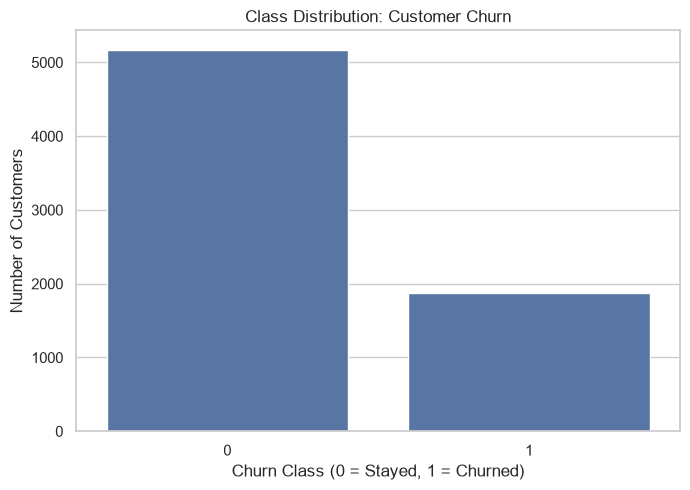

In [6]:
plt.figure(figsize=(7, 5))
sns.countplot(x=y)
plt.title("Class Distribution: Customer Churn")
plt.xlabel("Churn Class (0 = Stayed, 1 = Churned)")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig("viz_0_class_distribution.png", dpi=300)
plt.show()

### Interpretation

The class distribution shows that the churn class is smaller than the non-churn class. Because missing churners is particularly costly for the retention use case, model evaluation must pay close attention to **Recall, Precision, F1-score, and ROC-AUC**, rather than accuracy alone.

## 7. Train/Test Split

An **80/20 split** is used:

- 80% of observations → training
- 20% of observations → testing

`stratify=y` preserves approximately the same churn/non-churn proportion in both subsets. `random_state=42` makes the split reproducible.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
print("Training churn rate:", round(y_train.mean(), 4))
print("Testing churn rate:", round(y_test.mean(), 4))

Training set: (5634, 26)
Testing set: (1409, 26)
Training churn rate: 0.2654
Testing churn rate: 0.2654


## 8. Model Selection

Four classification algorithms are compared:

1. **Logistic Regression** — interpretable baseline and useful for estimating churn risk.
2. **Decision Tree** — captures nonlinear relationships and is easy to explain.
3. **Random Forest** — combines multiple trees and can model more complex patterns.
4. **Support Vector Machine (SVM)** — powerful classifier capable of learning complex decision boundaries.

`class_weight="balanced"` is used where supported so that the minority churn class receives greater importance.

In [8]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced", random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, class_weight="balanced", random_state=42
    ),
    "Support Vector Machine": CalibratedClassifierCV(
        SVC(class_weight="balanced", random_state=42), ensemble=False
    ),
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"{name} successfully trained.")

Logistic Regression successfully trained.
Decision Tree successfully trained.
Random Forest successfully trained.
Support Vector Machine successfully trained.


## 9. Model Evaluation

The following metrics are calculated for every model:

- **Accuracy:** Overall proportion of correct predictions.
- **Precision:** Proportion of predicted churners who actually churned.
- **Recall:** Proportion of actual churners correctly identified.
- **F1-score:** Harmonic mean of precision and recall.
- **ROC-AUC:** Measures how well the model separates churners from non-churners across thresholds.

Because the business objective emphasizes identifying churners, **Recall receives particular attention**.

In [9]:
results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
    })

df_results = pd.DataFrame(results).sort_values(
    by="Recall", ascending=False
).reset_index(drop=True)

df_results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7438,0.5113,0.7861,0.6196,0.8475
1,Random Forest,0.7722,0.5624,0.6390,0.5982,0.8252
2,Support Vector Machine,0.7892,0.5980,0.6283,0.6128,0.8289
3,Decision Tree,0.7331,0.4973,0.4920,0.4946,0.6566


## 10. Confusion Matrices — Charts 1–4

A confusion matrix shows four outcomes: true positives, true negatives, false positives, and false negatives. For churn prediction, the **false-negative cell is especially important** because it represents a customer who churned but was not identified by the model.

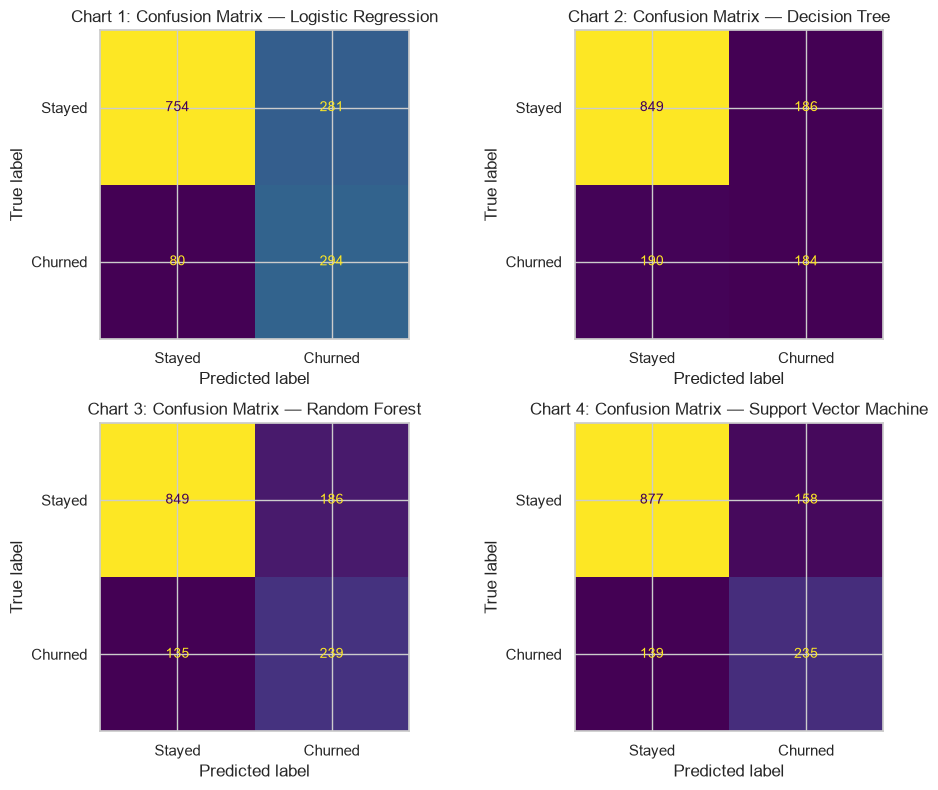

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for idx, (name, model) in enumerate(trained_models.items()):
    ConfusionMatrixDisplay.from_estimator(
        model, X_test, y_test, ax=axes[idx],
        colorbar=False, display_labels=["Stayed", "Churned"]
    )
    axes[idx].set_title(f"Chart {idx + 1}: Confusion Matrix — {name}")

plt.tight_layout()
plt.savefig("viz_1_to_4_confusion_matrices.png", dpi=300)
plt.show()

## 11. ROC Curves — Chart 5

The ROC curve compares the true-positive rate against the false-positive rate at different classification thresholds. A curve closer to the upper-left region generally indicates stronger discrimination.

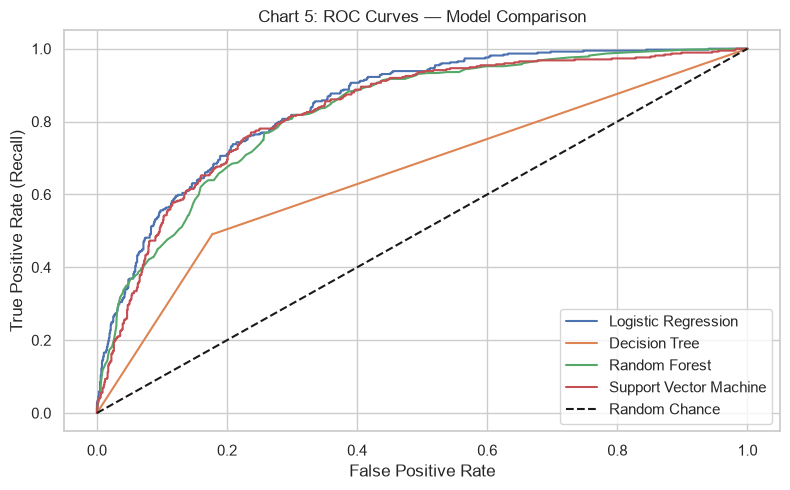

In [11]:
plt.figure(figsize=(8, 5))
for name, model in trained_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0, 1], [0, 1], "k--", label="Random Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("Chart 5: ROC Curves — Model Comparison")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("viz_5_roc_curves.png", dpi=300)
plt.show()

## 12. Precision-Recall Curves — Chart 6

Precision-Recall curves are especially useful when the positive class is less common. They show the trade-off between identifying more churners and maintaining precision.

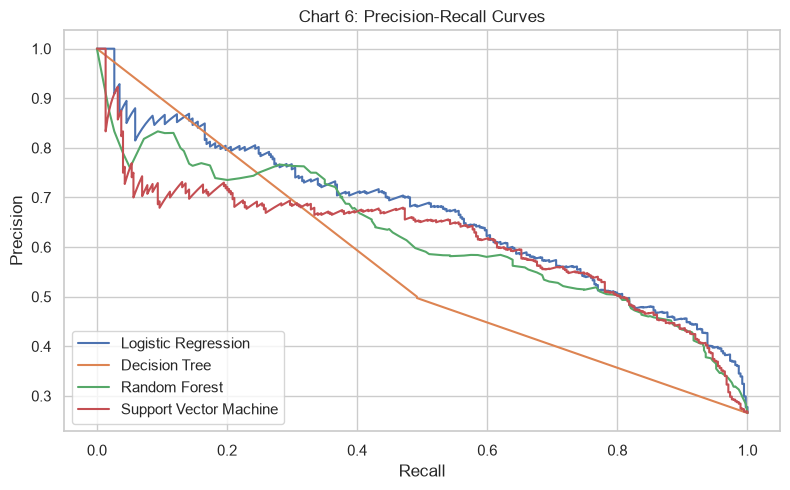

In [12]:
plt.figure(figsize=(8, 5))
for name, model in trained_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    plt.plot(recall, precision, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Chart 6: Precision-Recall Curves")
plt.legend(loc="lower left")
plt.tight_layout()
plt.savefig("viz_6_precision_recall_curves.png", dpi=300)
plt.show()

## 13. Model Performance Comparison — Chart 7

The following chart compares all five evaluation metrics across the four models. The chart should not be interpreted using accuracy alone; the final recommendation considers the business cost of missed churners.

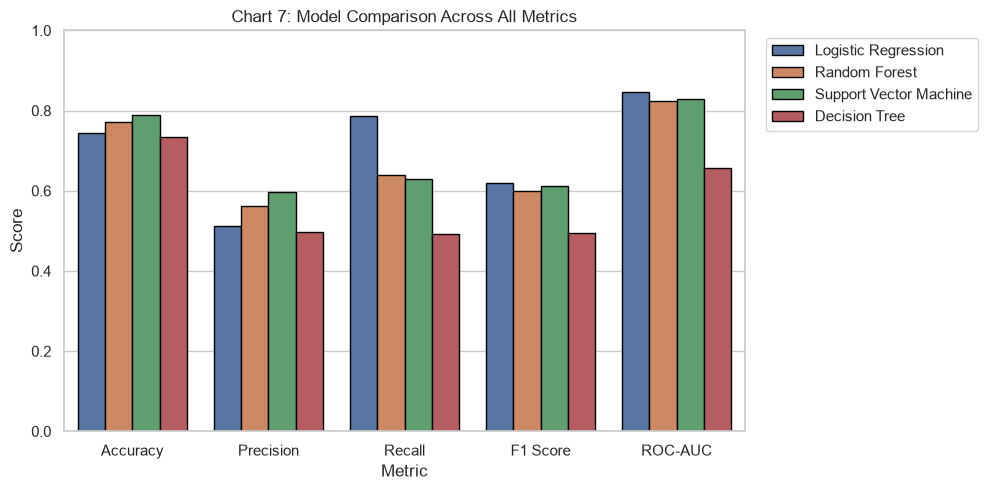

In [13]:
df_melted = df_results.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=df_melted, x="Metric", y="Score", hue="Model",
    edgecolor="black"
)
plt.title("Chart 7: Model Comparison Across All Metrics")
plt.ylim(0, 1.0)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("viz_7_model_comparison_bar.png", dpi=300)
plt.show()

## 14. Feature Importance — Chart 8

Logistic Regression coefficients are used as an interpretable measure of feature contribution.

- A **positive coefficient** indicates an association with increased predicted churn risk.
- A **negative coefficient** indicates an association with lower predicted churn risk.
- The magnitude indicates the strength of the association within the fitted model.

These are associations, not proof of causation.

Top 15 Logistic Regression features:


,Feature,Coefficient,Absolute_Importance
14,InternetService_Fiber optic,1.3347,1.3347
15,InternetService_No,-1.2106,1.2106
5,Avg_Monthly_Ratio,-1.1754,1.1754
1,tenure,-0.8647,0.8647
8,Encoded_Contract,-0.8082,0.8082
3,TotalCharges,0.4504,0.4504
13,MultipleLines_Yes,0.4212,0.4212
16,OnlineSecurity_Yes,-0.3941,0.3941
21,StreamingMovies_Yes,0.3787,0.3787
2,MonthlyCharges,0.3570,0.3570


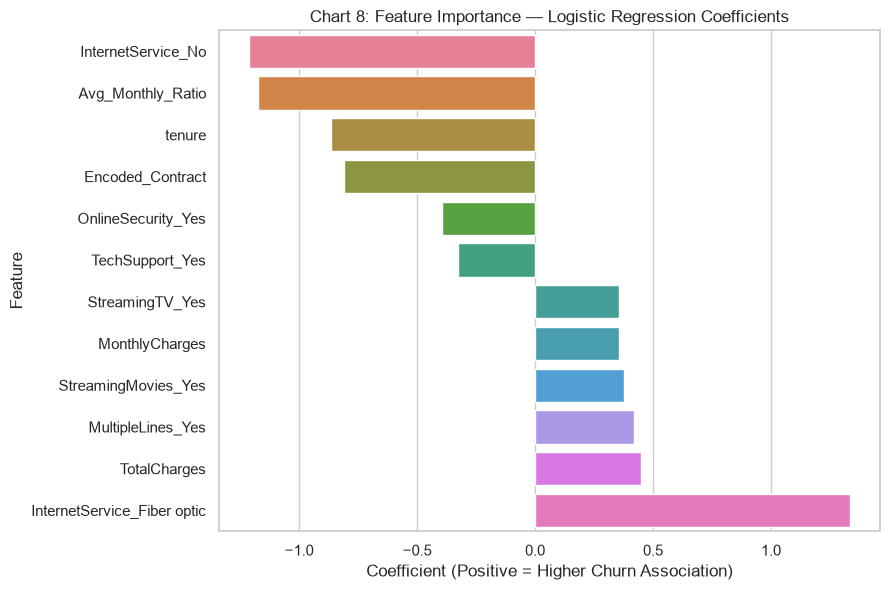

In [14]:
log_reg_model = trained_models["Logistic Regression"]
coefs = log_reg_model.coef_[0]

feat_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": coefs,
    "Absolute_Importance": np.abs(coefs)
}).sort_values("Absolute_Importance", ascending=False)

print("Top 15 Logistic Regression features:")
display(feat_df.head(15).round(4))

top_feat = pd.concat([
    feat_df.sort_values("Coefficient", ascending=False).head(6),
    feat_df.sort_values("Coefficient", ascending=True).head(6)
]).drop_duplicates("Feature")

plt.figure(figsize=(9, 6))
sns.barplot(
    data=top_feat.sort_values("Coefficient"),
    x="Coefficient", y="Feature", hue="Feature",
    legend=False
)
plt.title("Chart 8: Feature Importance — Logistic Regression Coefficients")
plt.xlabel("Coefficient (Positive = Higher Churn Association)")
plt.tight_layout()
plt.savefig("viz_8_feature_importance.png", dpi=300)
plt.show()

### Feature importance interpretation

The coefficient table should be interpreted together with the business context. Features with positive coefficients are associated with higher churn risk, while negative coefficients are associated with lower churn risk. The strongest features shown above provide useful candidates for retention analysis and stakeholder discussion.

**Important:** feature importance identifies statistical association within this model; it does not establish that a feature causes churn.

## 15. Prediction Probability Distribution — Chart 9

Logistic Regression produces a probability of churn for each customer. The default classification threshold is 0.50, meaning probabilities at or above 0.50 are classified as churn.

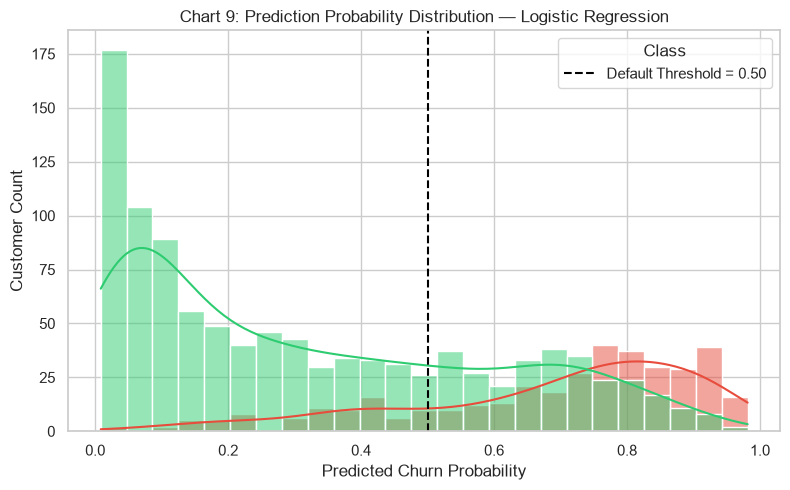

In [15]:
best_model = trained_models["Logistic Regression"]
y_probs = best_model.predict_proba(X_test)[:, 1]

plt.figure(figsize=(8, 5))
sns.histplot(
    x=y_probs, hue=y_test, kde=True, bins=25,
    palette={0: "#2ecc71", 1: "#e74c3c"}
)
plt.axvline(0.5, color="black", linestyle="--", label="Default Threshold = 0.50")
plt.title("Chart 9: Prediction Probability Distribution — Logistic Regression")
plt.xlabel("Predicted Churn Probability")
plt.ylabel("Customer Count")
plt.legend(title="Class")
plt.tight_layout()
plt.savefig("viz_9_probability_distribution.png", dpi=300)
plt.show()

## 16. Learning Curve — Chart 10

A learning curve compares training and cross-validation performance as the training set grows. It helps diagnose whether the model may benefit from more data or whether it is showing signs of high bias or variance.

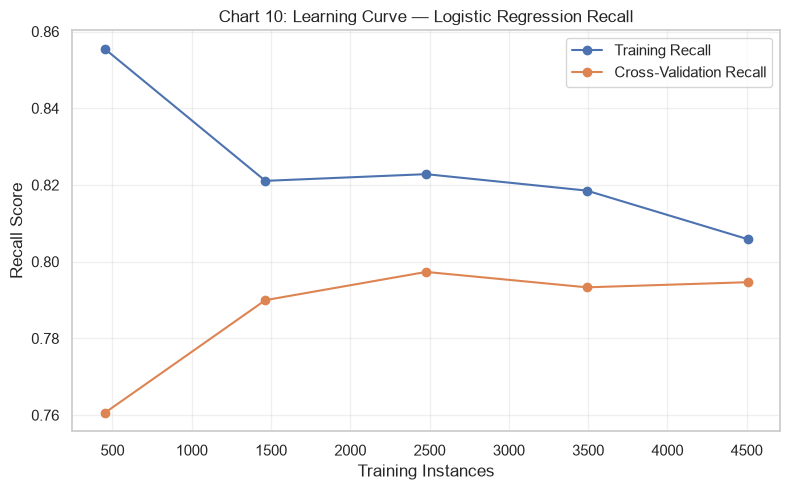

In [16]:
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train, y_train, cv=5, scoring="recall",
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, "o-", label="Training Recall")
plt.plot(train_sizes, val_mean, "o-", label="Cross-Validation Recall")
plt.title("Chart 10: Learning Curve — Logistic Regression Recall")
plt.xlabel("Training Instances")
plt.ylabel("Recall Score")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("viz_10_learning_curve.png", dpi=300)
plt.show()

## 17. Model Comparison: Technical and Business View

| Model | Main Advantage | Main Limitation | Interpretability | Business Suitability |
|---|---|---|---|---|
| Logistic Regression | Fast, interpretable, strong recall | Mostly linear decision relationship | High | **High** |
| Decision Tree | Easy to understand; captures nonlinear patterns | Can overfit | High | Medium |
| Random Forest | Strong nonlinear modelling and robustness | More computationally expensive and less transparent | Medium | High |
| SVM | Strong classification capability | Less interpretable and potentially more computationally demanding | Low–Medium | Medium |

### Why accuracy is not enough

SVM achieved the highest accuracy in the current results, but Logistic Regression achieved the highest recall. Since the business wants to identify as many actual churners as possible, recall is more directly aligned with the retention objective.

## 18. Current Model Results and Recommendation

Based on the current notebook results:

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---:|---:|---:|---:|---:|
| Logistic Regression | 74.38% | 51.13% | **78.61%** | **61.96%** | **84.75%** |
| Decision Tree | 73.31% | 49.73% | 49.20% | 49.46% | 65.66% |
| Random Forest | 77.22% | 56.24% | 63.90% | 59.82% | 82.52% |
| Support Vector Machine | **78.92%** | **59.80%** | 62.83% | 61.28% | 82.89% |

### Recommended model: Logistic Regression

Logistic Regression is recommended for the current business objective because it has the **highest recall (78.61%)** and a strong **ROC-AUC (84.75%)**. Although SVM has the highest accuracy, its recall is substantially lower.

This means Logistic Regression is currently better aligned with a retention strategy where the business prioritizes finding actual churners, even at the cost of contacting some customers who would not have churned.

The model is also relatively easy to explain to business stakeholders, which supports practical deployment and targeted retention campaigns.

## 19. Threshold Tuning — Business Optimization

The default probability threshold of 0.50 is not necessarily the best threshold for a churn-retention campaign. Lowering the threshold can increase recall, although precision may decrease.

Because the original business objective targeted approximately **80% recall**, the code below checks several thresholds. This is an additional analysis and should be evaluated on validation data in a production workflow.

In [17]:
threshold_rows = []
for threshold in np.arange(0.30, 0.71, 0.05):
    y_threshold = (y_probs >= threshold).astype(int)
    threshold_rows.append({
        "Threshold": round(threshold, 2),
        "Precision": precision_score(y_test, y_threshold, zero_division=0),
        "Recall": recall_score(y_test, y_threshold, zero_division=0),
        "F1": f1_score(y_test, y_threshold, zero_division=0)
    })

threshold_results = pd.DataFrame(threshold_rows)
display(threshold_results.round(4))

print("Thresholds achieving at least 80% recall:")
display(threshold_results[threshold_results["Recall"] >= 0.80].round(4))

,Threshold,Precision,Recall,F1
0,0.30,0.4318,0.9305,0.5898
1,0.35,0.4532,0.9064,0.6043
2,0.40,0.4673,0.8610,0.6058
3,0.45,0.4880,0.8182,0.6114
4,0.50,0.5113,0.7861,0.6196
5,0.55,0.5411,0.7567,0.6310
6,0.60,0.5614,0.7086,0.6265
7,0.65,0.5867,0.6604,0.6214
8,0.70,0.6310,0.5989,0.6145


Thresholds achieving at least 80% recall:


,Threshold,Precision,Recall,F1
0,0.30,0.4318,0.9305,0.5898
1,0.35,0.4532,0.9064,0.6043
2,0.40,0.4673,0.8610,0.6058
3,0.45,0.4880,0.8182,0.6114


### Threshold-tuning interpretation

If one or more thresholds achieve at least 80% recall, the business can consider using a lower threshold than 0.50 to capture more potential churners. However, the final threshold should be chosen using a validation set and a quantified business cost for false positives versus false negatives.

If no threshold reaches 80% recall without an unacceptable loss in precision, the model should be improved further through feature engineering, hyperparameter tuning, resampling/class-weight adjustments, or additional data.

## 20. Business Interpretation

The model results suggest several important implications for a telecommunications retention strategy:

1. **Early intervention matters.** Customers at higher predicted risk can be prioritized for proactive retention campaigns.
2. **Recall is strategically important.** Missing a genuine churner may result in lost recurring revenue.
3. **False positives have a cost.** Some customers flagged as high risk would have stayed, so campaigns should be targeted and cost-aware.
4. **Model explanations matter.** Logistic Regression provides a relatively transparent way to communicate why certain customer attributes are associated with churn risk.
5. **Predictions should support decisions, not replace them.** Customer service and marketing teams should combine model scores with business rules and customer context.

## 21. Limitations

- The current analysis uses the Week 2 processed dataset, so preprocessing leakage should be addressed in a production-grade pipeline by fitting transformations on training data only.
- The current models use largely default hyperparameters and have not undergone extensive hyperparameter tuning.
- Correlation and model coefficients describe associations rather than causation.
- The business cost of false positives and false negatives has not yet been quantified in monetary terms.
- A separate validation strategy would be preferable for selecting the final probability threshold before evaluating it on a final untouched test set.

## 22. Next Steps

1. Build a leakage-safe preprocessing and modelling Pipeline.
2. Perform cross-validation and hyperparameter tuning.
3. Quantify the financial cost of false positives and false negatives.
4. Optimize the decision threshold using validation data.
5. Investigate class balancing strategies such as class weights or resampling.
6. Validate the selected model on an untouched test set.
7. Package the model for deployment and monitoring.
8. Monitor post-deployment churn prediction performance and drift.

## 23. Final Conclusion

This project developed and evaluated four classification models for telecommunications customer churn prediction. Logistic Regression, Decision Tree, Random Forest, and Support Vector Machine were trained and compared using five evaluation metrics.

The analysis demonstrates why **model selection should be driven by the business problem rather than accuracy alone**. SVM produced the highest accuracy in the current experiment, while Logistic Regression produced the highest recall and a strong ROC-AUC. Because the retention strategy prioritizes identifying customers who are likely to churn, Logistic Regression is the current recommended model.

The project provides a foundation for the next stage: improving the modelling pipeline, tuning the decision threshold, and validating the model for practical deployment.